In [12]:
import pandas as pd

In [13]:
df = pd.read_csv('client_list_sample.csv')

In [14]:
df.head()

,client_id,days_since_activation,inactive_days,creation_date,mambu_state,first_transaction_date,last_transaction_date,total_loan_amount,total_inflow_amt,total_outflow_amt,total_billpayment_amt,total_savings_amt,ltv_credit,ltv_credit_no_risk,ltv_nocredit,ltv
0,A1N2ZY,2886,810,2018-02-20 09:11:09,ACTIVE,2023-08-13,2023-10-28,22519.0,296203.0000000000,295593.8900000000,0E-10,0E-10,1138.41,4758.22,2499.40,3637.81
1,CZVCMY,3010,2858,2017-10-19 12:53:52,EXITED,2017-10-27,2018-03-20,400000.0,True,True,True,True,94792.89,214141.00,0.00,94792.89
2,AOYY0U,2219,924,2019-12-19 06:48:21,ACTIVE,2019-12-27,2023-07-06,1150000.0,99500.0000000000,99459.9100000000,0E-10,0E-10,180534.66,601123.13,50.19,180584.85
3,2ZOE62,1133,58,2022-12-09 12:21:54,ACTIVE,2022-12-12,2025-11-18,456400.0,50000.0000000000,49900.0000000000,0E-10,0E-10,59459.81,195828.66,30.28,59490.09
4,CRPCF2,894,805,2023-08-05 10:28:43,INACTIVE,2023-11-02,2023-11-02,17648.0,True,True,True,True,531.93,3368.61,0.00,531.93


In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Clean dirty date columns (replace "True"/"False"/empty with NaT and parse)
for col in ["creation_date", "last_transaction_date"]:
    df[col] = df[col].replace(
        to_replace=["True", "False", "", None, "None"],
        value=pd.NaT
    )
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Monthly cohort based on account creation date
df["creation_month"] = df["creation_date"].dt.to_period("M")

# Active flag based on mambu_state
df["active"] = (df["mambu_state"] == "ACTIVE").astype(int)

# Cohort size (unique clients per month)
cohort_size = df.groupby("creation_month")["client_id"].nunique()

# Number of active clients per cohort (current status)
cohort_active = df.groupby("creation_month")["active"].sum()

# Retention and churn per cohort (very high-level, single number per cohort)
retention = (cohort_active / cohort_size).fillna(0)
churn = 1 - retention

# Mean LTV per cohort (monthly)
cohort_ltv_month = df.groupby("creation_month")["ltv"].mean()

print("Retention (by creation_month):")
print(retention)

print("\nChurn (by creation_month):")
print(churn)

print("\nMean LTV by cohort (creation_month):")
print(cohort_ltv_month)

Retention (by creation_month):
creation_month
2013-01    0.0
2013-02    0.0
2013-03    0.0
2013-04    0.0
2013-05    0.0
          ... 
2025-09    1.0
2025-10    1.0
2025-11    1.0
2025-12    1.0
2026-01    1.0
Freq: M, Length: 149, dtype: float64

Churn (by creation_month):
creation_month
2013-01    1.0
2013-02    1.0
2013-03    1.0
2013-04    1.0
2013-05    1.0
          ... 
2025-09    0.0
2025-10    0.0
2025-11    0.0
2025-12    0.0
2026-01    0.0
Freq: M, Length: 149, dtype: float64

Mean LTV by cohort (creation_month):
creation_month
2013-01    1.824921e+04
2013-02    1.010772e+05
2013-03    1.621342e+04
2013-04    1.007015e+06
2013-05    7.097794e+05
               ...     
2025-09    3.819816e+03
2025-10    8.287298e+03
2025-11    9.487197e+02
2025-12    9.223685e+03
2026-01    1.328292e+03
Freq: M, Name: ltv, Length: 149, dtype: float64


In [33]:
# Drop rows without valid dates for cohort analysis
df_q = df.dropna(subset=["creation_date", "last_transaction_date"]).copy()

# Quarterly cohorts
df_q["creation_quarter"] = df_q["creation_date"].dt.to_period("Q")
df_q["last_tx_quarter"] = df_q["last_transaction_date"].dt.to_period("Q")

# Cohort index: how many quarters since creation (Q0, Q1, Q2, ...)
df_q["cohort_index"] = (
    df_q["last_tx_quarter"].astype(int) - df_q["creation_quarter"].astype(int)
)

# Keep only non-negative indices
df_q = df_q[df_q["cohort_index"] >= 0]

# Optionally filter out very small cohorts to reduce noise
min_cohort_size = 30  # you can tune this
sizes_q = df_q.groupby("creation_quarter")["client_id"].nunique()
big_cohorts = sizes_q[sizes_q >= min_cohort_size].index
df_q = df_q[df_q["creation_quarter"].isin(big_cohorts)]

# Retention matrix: number of active clients per (cohort, cohort_index)
retention_counts = (
    df_q.groupby(["creation_quarter", "cohort_index"])["client_id"]
        .nunique()
        .unstack()
        .fillna(0)
)

# Normalize by cohort size at Q0 to get retention rate
cohort_sizes_q = retention_counts.iloc[:, 0].replace(0, np.nan)
retention_rate = retention_counts.divide(cohort_sizes_q, axis=0)

# LTV by quarterly cohort (mean; you can switch to median)
cohort_ltv_q = df_q.groupby("creation_quarter")["ltv"].mean()


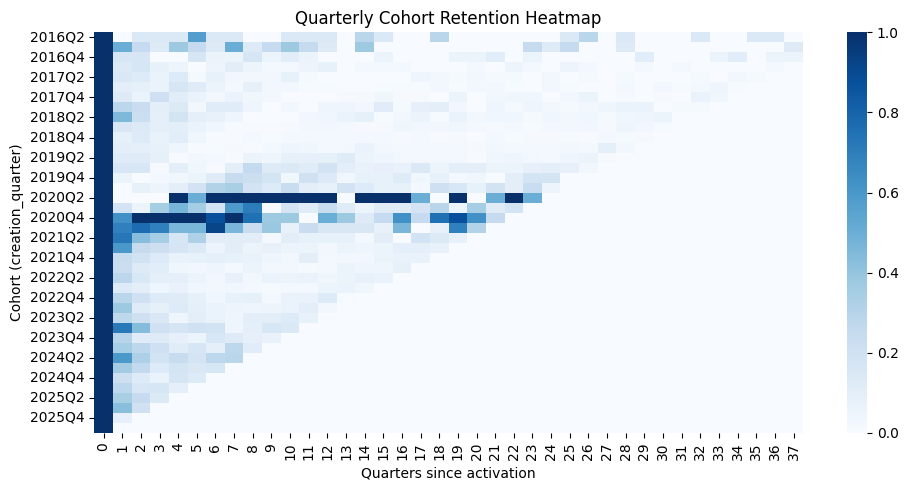

/var/folders/1p/24zktyks3xnftnwmc_7vqdvm0000gn/T/ipykernel_94087/1014645178.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


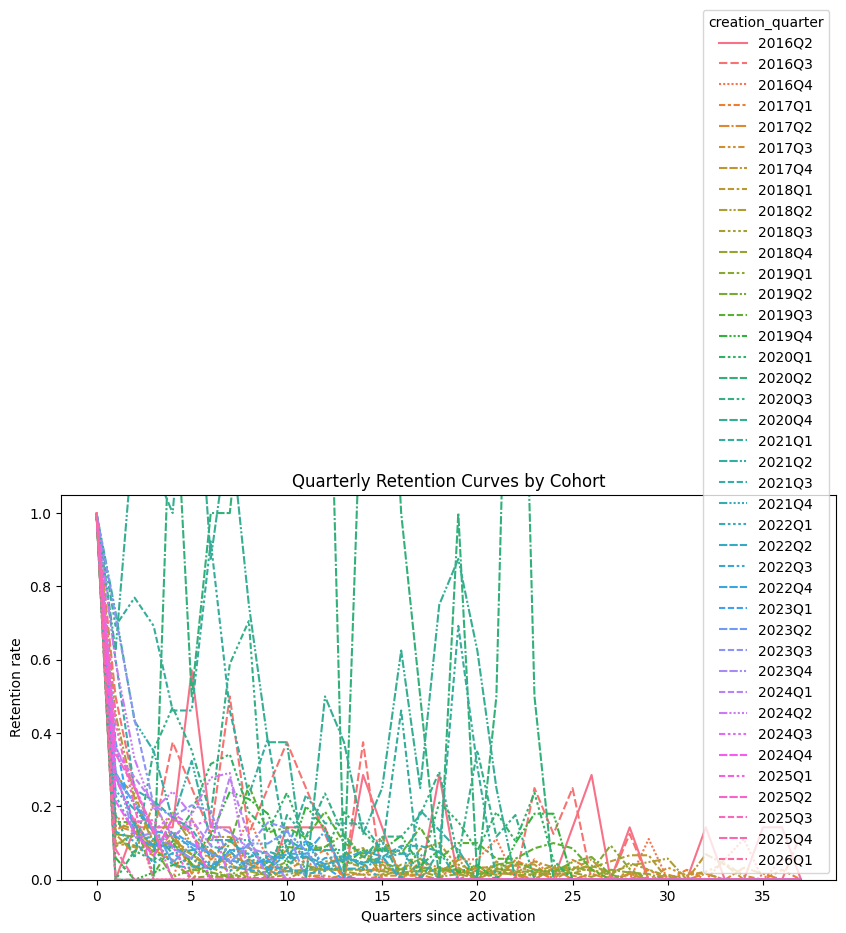

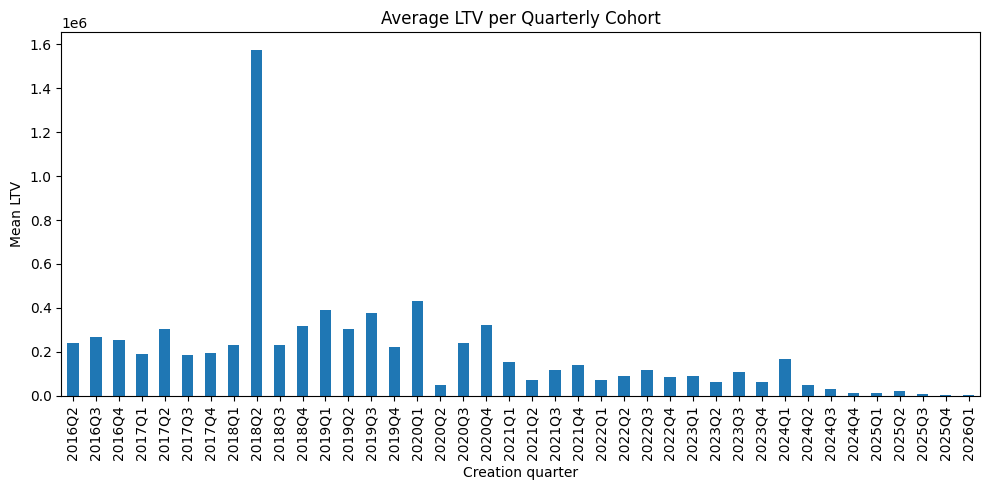

In [37]:
# Heatmap: quarterly cohort retention over time
plt.figure(figsize=(10, 5))
sns.heatmap(
    retention_rate,
    cmap="Blues",
    cbar=True,
    annot=False,     # no text labels, color only
    vmin=0,
    vmax=1
)
plt.title("Quarterly Cohort Retention Heatmap")
plt.ylabel("Cohort (creation_quarter)")
plt.xlabel("Quarters since activation")
plt.tight_layout()
plt.show()

# Retention curves by cohort (transpose to get time on X-axis)
plt.figure(figsize=(10, 5))
sns.lineplot(data=retention_rate.T)
plt.title("Quarterly Retention Curves by Cohort")
plt.xlabel("Quarters since activation")
plt.ylabel("Retention rate")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Average LTV per quarterly cohort
plt.figure(figsize=(10, 5))
cohort_ltv_q.plot(kind="bar")
plt.title("Average LTV per Quarterly Cohort")
plt.ylabel("Mean LTV")
plt.xlabel("Creation quarter")
plt.tight_layout()
plt.show()

Retention declines very quickly after acquisition, indicating high early churn.
LTV is mostly captured in the first cycle rather than over a long lifetime.
Activation and monetization need to happen early to matter.
Key points:
- Majority of users churn within the first quarter.
- Almost no cohorts show meaningful retention beyond Q1–Q2.
- LTV accrues at the start; later contribution is minimal.
- Retention curves are similar across cohorts, indicating a stable pattern of early drop-off.
- High churn suggests users do not form long-term habits in the product.
- Improving onboarding and first-use experience would have the largest impact.
- Acquisition quality matters more than long-term retention programs.
- Long-tail retention strategies are unlikely to pay off with the current pattern.
- Re-engagement should focus on the first 60–90 days; later attempts have low ROI.
Cohort differences are minor, so focus on early funnel improvements rather than long-term lifecycle